In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train , y_train) ,(x_test , y_test) = cifar10.load_data()

2026-02-22 15:33:41.790968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771774422.029118      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771774422.108947      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771774422.650455      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771774422.650507      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771774422.650510      55 computation_placer.cc:177] computation placer alr

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
x_test.shape

(10000, 32, 32, 3)

In [7]:
y_test.shape

(10000, 1)

In [8]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [9]:
# normilize the filtting them 0 to 1
x_train , x_test = x_train / 255.0 , x_test / 255.0

In [10]:
print(x_train[0])

[[[0.23137255 0.24313725 0.24705882]
  [0.16862745 0.18039216 0.17647059]
  [0.19607843 0.18823529 0.16862745]
  ...
  [0.61960784 0.51764706 0.42352941]
  [0.59607843 0.49019608 0.4       ]
  [0.58039216 0.48627451 0.40392157]]

 [[0.0627451  0.07843137 0.07843137]
  [0.         0.         0.        ]
  [0.07058824 0.03137255 0.        ]
  ...
  [0.48235294 0.34509804 0.21568627]
  [0.46666667 0.3254902  0.19607843]
  [0.47843137 0.34117647 0.22352941]]

 [[0.09803922 0.09411765 0.08235294]
  [0.0627451  0.02745098 0.        ]
  [0.19215686 0.10588235 0.03137255]
  ...
  [0.4627451  0.32941176 0.19607843]
  [0.47058824 0.32941176 0.19607843]
  [0.42745098 0.28627451 0.16470588]]

 ...

 [[0.81568627 0.66666667 0.37647059]
  [0.78823529 0.6        0.13333333]
  [0.77647059 0.63137255 0.10196078]
  ...
  [0.62745098 0.52156863 0.2745098 ]
  [0.21960784 0.12156863 0.02745098]
  [0.20784314 0.13333333 0.07843137]]

 [[0.70588235 0.54509804 0.37647059]
  [0.67843137 0.48235294 0.16470588]


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

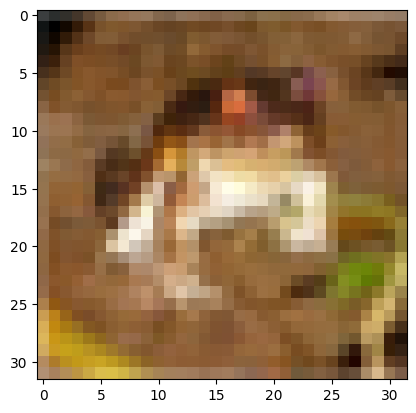

In [12]:
plt.imshow(x_train[0])
plt.show()

In [13]:
arr = y_train[0]
print(arr)

[6]


In [14]:
class_name = ['airplane' , 'automobile' ,'bird' ,'cat' ,'deer' ,'dog' ,'frog', 'horse' ,'ship' ,'truck']

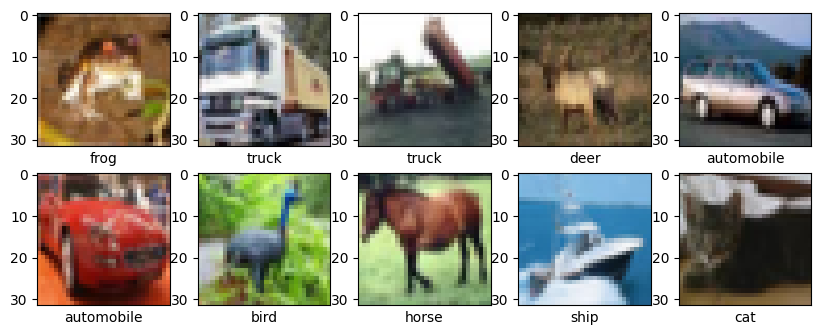

In [15]:
plt.figure(figsize = (10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_name[y_train[i][0]])

In [16]:
from tensorflow.keras import utils
y_train =utils.to_categorical(y_train,10)
y_test =utils.to_categorical(y_test,10)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [20]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [21]:
model = Sequential(
    [
        Dense(64,input_shape = (32,32,3)),
        Conv2D(64 ,kernel_size = (3,3), activation = 'relu'),
        Conv2D(64 ,(3,3), activation = 'relu'),
        MaxPooling2D(pool_size = (2,2)),
        Conv2D(128 ,(3,3), activation = 'relu'),
        Conv2D(128 ,(3,3), activation = 'relu'),
        MaxPooling2D(pool_size = (2,2)),
        Dropout(0.5),
        Flatten(),
        Dense(128 , activation = 'relu'),
        Dense(10 , activation = 'softmax')  
    ]
)

In [22]:
model.compile(loss ='categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy']             
             )

In [24]:
history = model.fit(
    x_train, y_train,
    batch_size = 32,
    epochs = 10,
    verbose = 1,
    validation_data = (x_test , y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 303s 192ms/step - accuracy: 0.3402 - loss: 1.7756 - val_accuracy: 0.5795 - val_loss: 1.1683
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 294s 188ms/step - accuracy: 0.6045 - loss: 1.1141 - val_accuracy: 0.6715 - val_loss: 0.9411
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 299s 191ms/step - accuracy: 0.6771 - loss: 0.9163 - val_accuracy: 0.7091 - val_loss: 0.8354
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 292s 187ms/step - accuracy: 0.7159 - loss: 0.8111 - val_accuracy: 0.7381 - val_loss: 0.7578
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 291s 186ms/step - accuracy: 0.7468 - loss: 0.7210 - val_accuracy: 0.7419 - val_loss: 0.7404
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 293s 187ms/step - accuracy: 0.7606 - loss: 0.6786 - val_accuracy: 0.7594 - val_loss: 0.6973
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 292s 187ms/step - accuracy: 0.7850 - loss: 0.6152 - val_accuracy: 0.7679 - val_loss: 0.6890
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 328s 190ms/step - ac

In [25]:
val_loss , val_acc = model.evaluate(x_test, y_test)
print(val_loss , val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7829 - loss: 0.6447
0.6598520874977112 0.7792999744415283


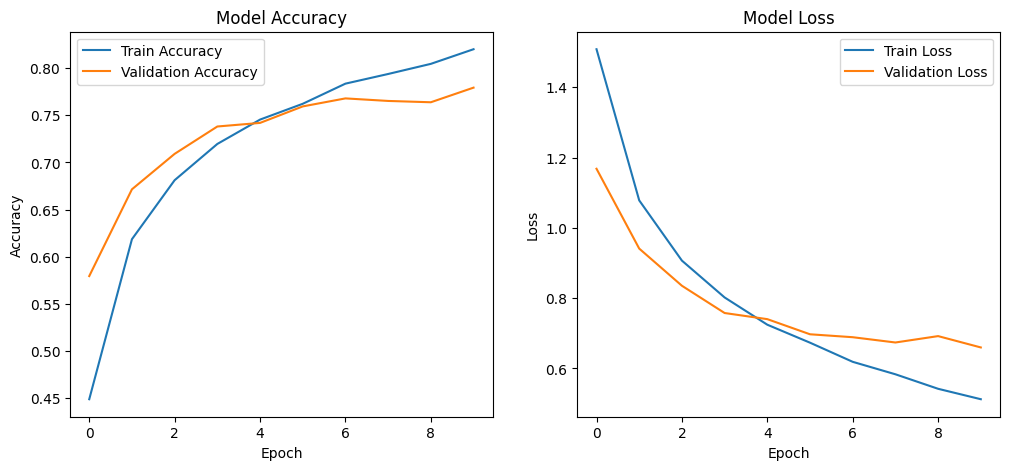

In [26]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [27]:
model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [28]:
model1.compile(loss ='categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy']             
             )

In [29]:
history = model1.fit(
    x_train, y_train,
    batch_size = 32,
    epochs = 10,
    verbose = 1,
    validation_data = (x_test , y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.3486 - loss: 1.7592 - val_accuracy: 0.5484 - val_loss: 1.2297
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5768 - loss: 1.1840 - val_accuracy: 0.6440 - val_loss: 1.0024
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6478 - loss: 0.9957 - val_accuracy: 0.6902 - val_loss: 0.8717
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6854 - loss: 0.8937 - val_accuracy: 0.7106 - val_loss: 0.8300
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7103 - loss: 0.8228 - val_accuracy: 0.7279 - val_loss: 0.7805
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7331 - loss: 0.7586 - val_accuracy: 0.7274 - val_loss: 0.7772
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7477 - loss: 0.7201 - val_accuracy: 0.7491 - val_loss: 0.7425
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7610 -

In [30]:
arr = model.predict([x_train[0].reshape(1,32,32,3)])
label = np.argmax(arr)
print(label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
6


In [31]:
model.save("cnn_model.keras")

In [32]:
from tensorflow.keras.models import load_model
model = load_model("cnn_model.keras")